In [1]:
import cv2 
import numpy as np
import matplotlib.pyplot as plt

## Import Library

Sebelum memulai proses pengolahan citra, kita perlu mengimpor beberapa library Python yang akan digunakan sepanjang praktikum ini.

- **`cv2` (OpenCV)** — Library utama untuk pengolahan citra digital. Digunakan untuk membaca gambar, konversi warna (BGR↔Grayscale), operasi geometri (flip, rotasi, translasi, resize), dan konvolusi.

- **`numpy` (diimport sebagai `np`)** — Library untuk komputasi numerik berbasis array/matriks. Dalam konteks PCD, citra digital pada dasarnya adalah matriks 2D (grayscale) atau 3D (RGB/BGR) dari nilai piksel, sehingga numpy sangat penting untuk memanipulasi nilai-nilai tersebut secara efisien.

- **`matplotlib.pyplot` (diimport sebagai `plt`)** — Library untuk visualisasi data dan gambar. Digunakan untuk menampilkan citra, membuat subplot, dan memplot histogram distribusi intensitas piksel.

Ketiga library ini merupakan fondasi utama dalam ekosistem pengolahan citra berbasis Python, dan akan digunakan secara konsisten di seluruh tahapan praktikum ini.

In [2]:
imgA = cv2.imread('assets/Dino-A.png')
imgB = cv2.imread('assets/Dino-B.png')
imgC = cv2.imread('assets/Dino-C.png')
imgD = cv2.imread('assets/Dino-D.png')

kacamata = cv2.imread('assets/Kacamata.png', cv2.IMREAD_UNCHANGED)
money = cv2.imread('assets/Money.png', cv2.IMREAD_UNCHANGED)
udud = cv2.imread('assets/Udud.png', cv2.IMREAD_UNCHANGED)

## Load Gambar (Membaca File Citra)

Sebelum dapat diproses, seluruh file gambar harus dimuat ke dalam memori terlebih dahulu
menggunakan fungsi `cv2.imread()`.

### Potongan Dino (A, B, C, D)
```python
imgA = cv2.imread('assets/Dino-A.png')
imgB = cv2.imread('assets/Dino-B.png')
imgC = cv2.imread('assets/Dino-C.png')
imgD = cv2.imread('assets/Dino-D.png')
```
Keempat gambar ini adalah potongan karakter Dino yang terbagi menjadi 4 bagian (A, B, C, D).
`cv2.imread()` membaca file gambar dan menyimpannya sebagai array NumPy 3 dimensi dengan
format **BGR** (Blue-Green-Red) — bukan RGB seperti umumnya. Hasilnya berupa matriks
berukuran `(tinggi, lebar, 3)` di mana angka `3` mewakili 3 channel warna.

> ⚠️ Jika file tidak ditemukan, `cv2.imread()` akan mengembalikan `None` — bukan error.
> Pastikan path dan nama file sudah benar.

### Atribut Sultan (Kacamata, Money, Udud)
```python
kacamata = cv2.imread('assets/Kacamata.png', cv2.IMREAD_UNCHANGED)
money    = cv2.imread('assets/Money.png',    cv2.IMREAD_UNCHANGED)
udud     = cv2.imread('assets/Udud.png',     cv2.IMREAD_UNCHANGED)
```
Ketiga gambar atribut ini dibaca menggunakan flag tambahan **`cv2.IMREAD_UNCHANGED`**.

Perbedaannya dengan pembacaan biasa:

| Flag | Channel yang dibaca | Kegunaan |
|------|-------------------|----------|
| Default (tanpa flag) | BGR (3 channel) | Gambar biasa tanpa transparansi |
| `cv2.IMREAD_UNCHANGED` | BGRA (4 channel) | Mempertahankan channel **Alpha (transparansi)** |

Channel **Alpha** adalah channel ke-4 yang menyimpan informasi transparansi setiap piksel
(0 = transparan penuh, 255 = solid penuh). Flag ini wajib digunakan pada gambar atribut
karena background-nya transparan/hitam, sehingga saat ditempelkan ke Dino tidak akan
menutupi gambar di belakangnya.

In [3]:
A = cv2.cvtColor(imgA, cv2.COLOR_BGR2GRAY)
B = cv2.cvtColor(imgB, cv2.COLOR_BGR2GRAY)
C = cv2.cvtColor(imgC, cv2.COLOR_BGR2GRAY)
D = cv2.cvtColor(imgD, cv2.COLOR_BGR2GRAY)

## Konversi Citra ke Grayscale

Keempat potongan Dino dikonversi dari format warna **BGR** menjadi **Grayscale** 
menggunakan `cv2.cvtColor()` dengan parameter `cv2.COLOR_BGR2GRAY`.

Proses ini mengubah array 3 dimensi `(tinggi, lebar, 3)` menjadi array 2 dimensi 
`(tinggi, lebar)`, di mana setiap piksel kini hanya memiliki **satu nilai intensitas** 
antara 0 (hitam) hingga 255 (putih).

Rumus konversi yang digunakan OpenCV adalah:

**Y = 0.114×B + 0.587×G + 0.299×R**

Konversi ke grayscale dilakukan karena:
1. Mempermudah analisis visual — perbedaan terang-gelap lebih mudah diamati
2. Mengurangi kompleksitas data dari 3 channel menjadi 1 channel
3. Seluruh operasi geometri berikutnya (flip, rotasi, translasi, dilatasi) 
   cukup dilakukan pada 1 channel saja

## Menampilkan Citra Grayscale

Keempat potongan Dino yang telah dikonversi ke grayscale ditampilkan sekaligus 
dalam satu figure menggunakan `plt.subplots(2, 2)` yang membuat layout grid 
**2 baris × 2 kolom**, dengan ukuran figure `6×6` inci.

Setiap potongan ditampilkan pada posisinya masing-masing:
- `ax[0,0]` → Potongan **A** (kiri atas)
- `ax[0,1]` → Potongan **B** (kanan atas)  
- `ax[1,0]` → Potongan **C** (kiri bawah)
- `ax[1,1]` → Potongan **D** (kanan bawah)

Parameter `cmap='gray'` digunakan agar matplotlib menampilkan array 2D 
sebagai citra abu-abu, bukan warna lain.

`ax.ravel()` mengubah array 2D dari subplot menjadi array 1D sehingga bisa 
diiterasi sekaligus untuk menonaktifkan sumbu (`axis('off')`) pada semua panel 
sekaligus tanpa perlu menulis satu per satu.

`plt.tight_layout()` secara otomatis menyesuaikan jarak antar subplot agar 
tidak saling tumpang tindih.

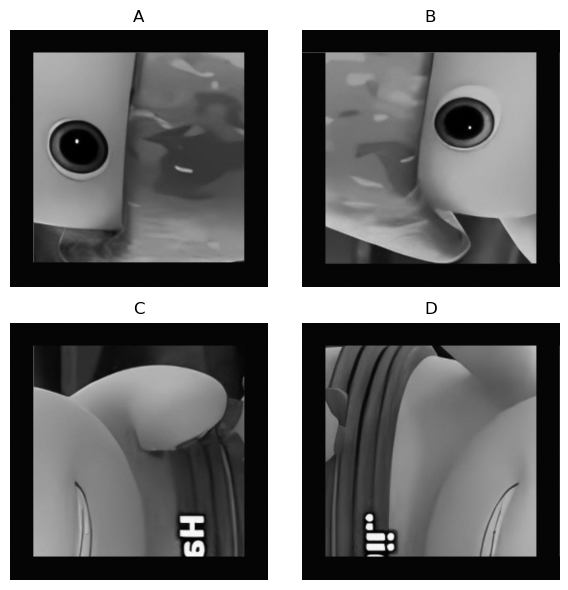

In [4]:
fig, ax = plt.subplots(2,2, figsize=(6,6))

ax[0,0].imshow(A, cmap='gray')
ax[0,0].set_title('A')

ax[0,1].imshow(B, cmap='gray')
ax[0,1].set_title('B')

ax[1,0].imshow(C, cmap='gray')
ax[1,0].set_title('C')

ax[1,1].imshow(D, cmap='gray')
ax[1,1].set_title('D')

for a in ax.ravel():
    a.axis('off')

plt.tight_layout()
plt.show()

## Pencerminan (Image Flipping)

Tahap ini melakukan pencerminan pada potongan yang orientasinya belum sesuai.
Setelah diamati, potongan **C** dan **D** terlihat terbalik secara horizontal,
sehingga perlu dicerminkan agar dapat disusun dengan benar.

`cv2.flip()` bekerja dengan parameter `flipCode`:
| flipCode | Efek |
|----------|------|
| `0` | Cermin vertikal (atas-bawah) |
| `1` | Cermin horizontal (kiri-kanan) |
| `-1` | Cermin keduanya |

- **A & B** → Tidak perlu dicerminkan, cukup disalin dengan `.copy()` agar 
  tidak memodifikasi array aslinya
- **C & D** → Dicerminkan horizontal (`flipCode=1`) karena posisi kiri-kanan 
  pikselnya terbalik terhadap susunan akhir yang diinginkan

Secara matematis, pencerminan horizontal memindahkan piksel pada kolom `x` 
ke kolom `(lebar - 1 - x)`, sehingga:

**hasil[y][x] = asli[y][lebar - 1 - x]**

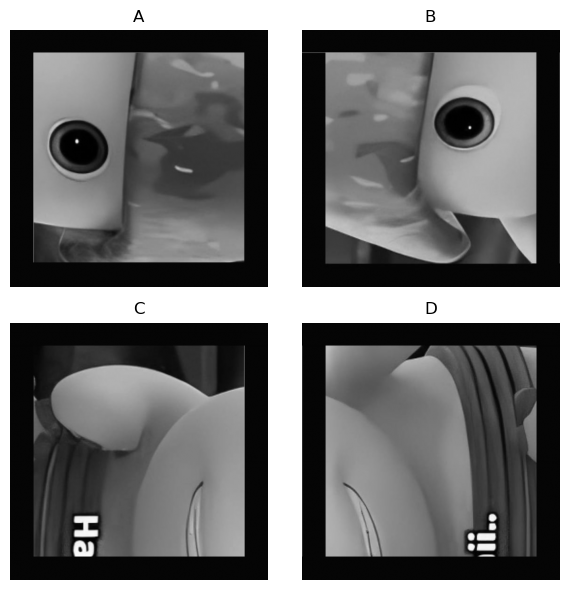

In [5]:
flipA = A.copy()  
flipB = B.copy()  
flipC = cv2.flip(C, 1) 
flipD = cv2.flip(D, 1)  

fig, ax = plt.subplots(2,2, figsize=(6,6))

ax[0,0].imshow(flipA, cmap='gray')
ax[0,0].set_title('A')

ax[0,1].imshow(flipB, cmap='gray')
ax[0,1].set_title('B')

ax[1,0].imshow(flipC, cmap='gray')
ax[1,0].set_title('C')

ax[1,1].imshow(flipD, cmap='gray')
ax[1,1].set_title('D')

for a in ax.ravel():
    a.axis('off')

plt.tight_layout()
plt.show()

## Rotasi Citra

Tahap ini merotasi setiap potongan agar orientasinya sejajar dan siap disusun.
`cv2.rotate()` mendukung tiga pilihan sudut rotasi:

| Parameter | Efek |
|-----------|------|
| `cv2.ROTATE_90_CLOCKWISE` | Putar 90° searah jarum jam |
| `cv2.ROTATE_90_COUNTERCLOCKWISE` | Putar 90° berlawanan jarum jam |
| `cv2.ROTATE_180` | Putar 180° |

Rotasi yang diterapkan pada masing-masing potongan:
- **A** → Diputar 90° berlawanan jarum jam
- **B** → Diputar 90° searah jarum jam, lalu dicerminkan horizontal — 
  kombinasi dua operasi ini diperlukan karena rotasi 90° saja belum 
  menghasilkan orientasi yang tepat, sehingga dibutuhkan flip tambahan 
  untuk mengoreksi posisi kiri-kanan. Hasil rotasi sementara disimpan 
  di `_temp_rotB` agar tidak mengotori variabel lain
- **C** → Diputar 90° berlawanan jarum jam
- **D** → Diputar 90° searah jarum jam

Secara matematis, rotasi 90° searah jarum jam memindahkan piksel `(y, x)` 
ke posisi baru `(x, tinggi - 1 - y)`, sedangkan rotasi berlawanan jarum jam 
memindahkan `(y, x)` ke `(lebar - 1 - x, y)`.

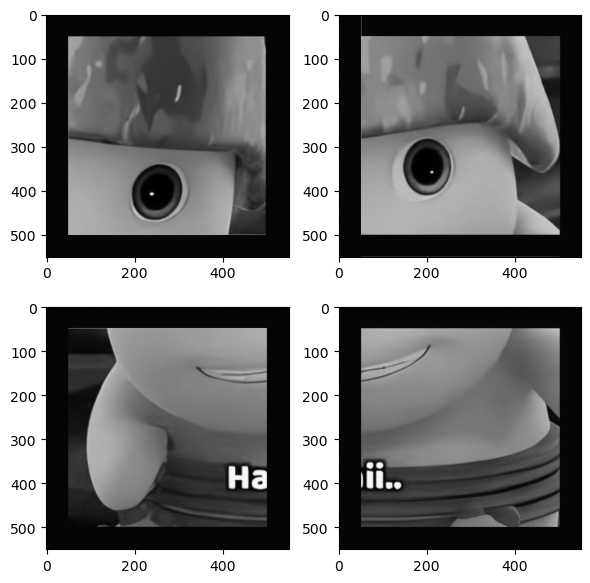

In [6]:
rotA = cv2.rotate(flipA, cv2.ROTATE_90_COUNTERCLOCKWISE)
rotC = cv2.rotate(flipC, cv2.ROTATE_90_COUNTERCLOCKWISE)
rotD = cv2.rotate(flipD, cv2.ROTATE_90_CLOCKWISE)

_temp_rotB = cv2.rotate(flipB, cv2.ROTATE_90_CLOCKWISE)
rotB = cv2.flip(_temp_rotB, 1)

fig, ax = plt.subplots(2, 2, figsize=(6, 6))

ax[0,0].imshow(rotA, cmap='gray')
ax[0,1].imshow(rotB, cmap='gray')
ax[1,0].imshow(rotC, cmap='gray')
ax[1,1].imshow(rotD, cmap='gray')

plt.tight_layout()
plt.show()

## ↔️ Translasi Citra

Translasi adalah operasi menggeser posisi piksel citra sebesar nilai tertentu 
pada sumbu X (horizontal) dan/atau sumbu Y (vertikal).

Operasi ini dilakukan menggunakan `cv2.warpAffine()` dengan **matriks transformasi affine** 
berukuran 2×3 sebagai berikut:

Di mana `tx` = pergeseran horizontal dan `ty` = pergeseran vertikal.
Nilai **positif** = geser ke kanan/bawah, nilai **negatif** = geser ke kiri/atas.

Pergeseran yang diterapkan pada masing-masing potongan:

| Potongan | tx | ty | Arah Geser |
|----------|----|----|------------|
| A | +50 | +50 | Kanan & Bawah |
| B | -50 | +50 | Kiri & Bawah |
| C | +50 | -50 | Kanan & Atas |
| D | -50 | -50 | Kiri & Atas |

Arah pergeseran yang berlawanan pada setiap potongan ini dirancang agar saat 
digabungkan nanti, tepi-tepi potongan dapat saling bertemu dengan rapi di bagian tengah.

`rows, cols = rotA.shape[:2]` digunakan untuk mengambil dimensi citra, yang kemudian 
dipakai sebagai ukuran output `(cols, rows)` pada `cv2.warpAffine()` agar ukuran 
citra tidak berubah setelah translasi.

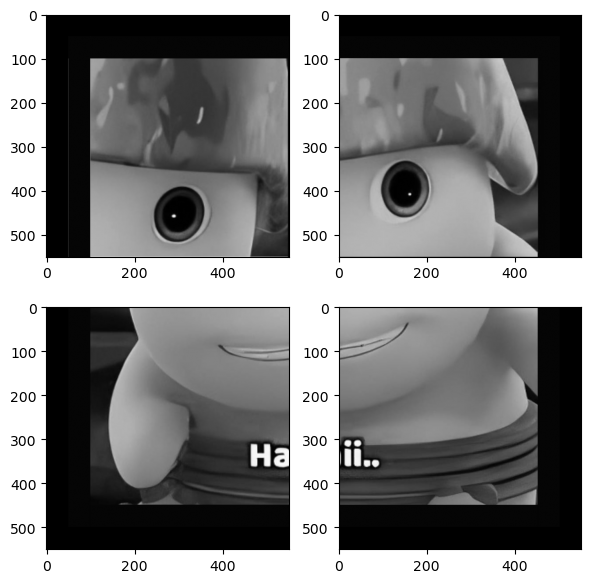

In [ ]:
rows, cols = rotA.shape[:2]

M_A = np.float32([[1, 0, 50], [0, 1, 50]])
transA = cv2.warpAffine(rotA, M_A, (cols, rows))
M_B = np.float32([[1, 0, -50], [0, 1, 50]])
transB = cv2.warpAffine(rotB, M_B, (cols, rows))
M_C = np.float32([[1, 0, 50], [0, 1, -50]])
transC = cv2.warpAffine(rotC, M_C, (cols, rows))
M_D = np.float32([[1, 0, -50], [0, 1, -50]])
transD = cv2.warpAffine(rotD, M_D, (cols, rows))

fig, ax = plt.subplots(2, 2, figsize=(6, 6))

ax[0,0].imshow(transA, cmap='gray')
ax[0,1].imshow(transB, cmap='gray')
ax[1,0].imshow(transC, cmap='gray')
ax[1,1].imshow(transD, cmap='gray')

plt.tight_layout()
plt.show()

## Crop, Dilatasi, dan Penggabungan Citra

### 1. Crop (Pemotongan Area Hitam)
Setelah translasi, setiap potongan memiliki **area hitam kosong** di sisi tertentu 
akibat pergeseran piksel. Area hitam ini dipotong menggunakan slicing NumPy:

| Potongan | Area yang dipotong | Alasan |
|----------|--------------------|--------|
| A | Atas (0-50) & Kiri (0-50) | Translasi ke kanan+bawah → hitam di atas & kiri |
| B | Atas (0-50) & Kanan (cols-50) | Translasi ke kiri+bawah → hitam di atas & kanan |
| C | Bawah (rows-50) & Kiri (0-50) | Translasi ke kanan+atas → hitam di bawah & kiri |
| D | Bawah (rows-50) & Kanan (cols-50) | Translasi ke kiri+atas → hitam di bawah & kanan |

### 2. Dilatasi (Resize kembali ke ukuran semula)
Setelah crop, ukuran tiap potongan menjadi lebih kecil `(rows-50, cols-50)`. 
Maka `cv2.resize()` digunakan untuk mengembalikan ukurannya ke `(cols, rows)` 
agar semua potongan memiliki ukuran yang seragam sebelum digabung.

Proses ini disebut **dilatasi** karena secara efektif memperbesar kembali 
citra yang telah dipotong — setiap piksel "diregangkan" untuk mengisi ruang yang lebih besar.

### 3. Penggabungan (Concatenate)
Keempat potongan digabungkan menjadi satu citra utuh:
- `cv2.hconcat()` → menggabungkan secara **horizontal** (kiri-kanan):
  - `top_half` = dilA + dilB
  - `bottom_half` = dilC + dilD
- `cv2.vconcat()` → menggabungkan secara **vertikal** (atas-bawah):
  - `final_image` = top_half + bottom_half

### 4. Resize Akhir
`final_image` di-resize ke ukuran `(1850, 1700)` sebagai penyesuaian 
skala akhir agar proporsi citra sesuai dengan kanvas yang akan digunakan 
pada tahap penambahan atribut sultan berikutnya.

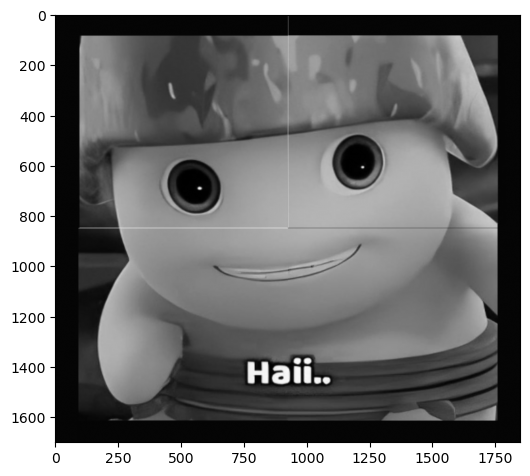

In [ ]:
cropA = transA[50:rows, 50:cols]
cropB = transB[50:rows, 0:cols-50]
cropC = transC[0:rows-50, 50:cols]
cropD = transD[0:rows-50, 0:cols-50]

dilA = cv2.resize(cropA, (cols, rows))
dilB = cv2.resize(cropB, (cols, rows))
dilC = cv2.resize(cropC, (cols, rows))
dilD = cv2.resize(cropD, (cols, rows))

top_half = cv2.hconcat([dilA, dilB])
bottom_half = cv2.hconcat([dilC, dilD])

final_image = cv2.vconcat([top_half, bottom_half])

final_image_resized = cv2.resize(final_image, (1850, 1700))

plt.figure(figsize=(6, 6))
plt.imshow(final_image_resized, cmap='gray') 
plt.show()

## Menampilkan Atribut Sultan

Sebelum ditempelkan ke citra Dino, ketiga atribut sultan ditampilkan terlebih 
dahulu untuk memastikan gambar terbaca dengan benar.

### Kanvas
`CANVAS_W = 1500` dan `CANVAS_H = 1850` mendefinisikan ukuran referensi kanvas 
yang akan digunakan sebagai acuan koordinat tampilan — bukan ukuran gambar aslinya.

### Fungsi `to_rgba()`
Fungsi ini menstandarisasi format semua gambar menjadi **RGBA (4 channel)** 
agar konsisten saat ditampilkan. Tiga kondisi yang ditangani:

| Kondisi | Konversi |
|---------|----------|
| Grayscale (2D) | `GRAY → RGBA` |
| BGRA (4 channel) | `BGRA → RGBA` (tukar urutan channel) |
| BGR (3 channel) | `BGR → RGB` |

Konversi ini penting karena OpenCV menyimpan warna dalam format **BGR** 
sedangkan Matplotlib menampilkan dalam format **RGB/RGBA** — jika tidak 
dikonversi, warna merah dan biru akan tertukar.

### Menampilkan Atribut
Ketiga atribut ditampilkan dalam layout **1 baris × 3 kolom** dengan 
background hitam (`facecolor="black"`).

Parameter `extent=[0, CANVAS_W, CANVAS_H, 0]` memaksa gambar ditampilkan 
dalam sistem koordinat kanvas `(0–1500 untuk X, 0–1850 untuk Y)`, sehingga 
sumbu yang tampil sesuai dengan koordinat yang akan digunakan saat penempelan atribut.

`set_xticks([0, 500, 1000, 1500])` menentukan label sumbu X agar hanya 
menampilkan angka kelipatan 500.

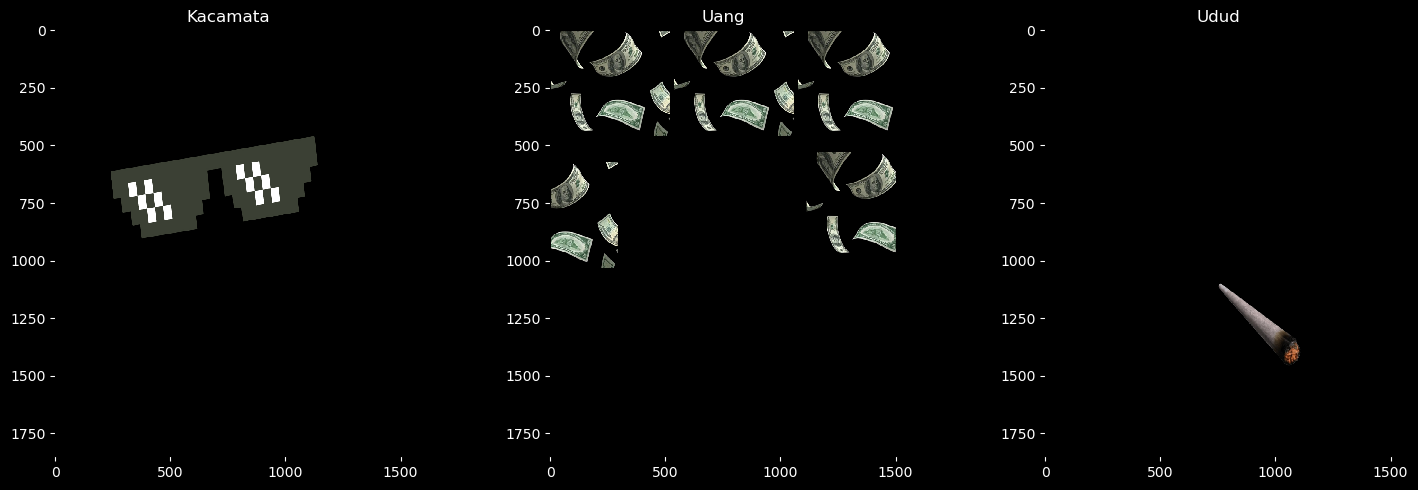

In [153]:
CANVAS_W, CANVAS_H = 1500, 1850

def to_rgba(img):
    if img is None:
        raise ValueError("Image belum kebaca.")
    if len(img.shape) == 2:
        return cv2.cvtColor(img, cv2.COLOR_GRAY2RGBA)
    if img.shape[2] == 4:
        return cv2.cvtColor(img, cv2.COLOR_BGRA2RGBA)
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

items = [
    ("Kacamata", kacamata),
    ("Uang", money),
    ("Udud", udud),
]

fig, axes = plt.subplots(1, 3, figsize=(15, 5), facecolor="black")

for ax, (title, img) in zip(axes, items):
    rgba = to_rgba(img)
    ax.imshow(rgba, extent=[0, CANVAS_W, CANVAS_H, 0], interpolation="nearest")
    ax.set_title(title, color="white")
    ax.set_facecolor("black")
    ax.set_xlim(0, CANVAS_W)
    ax.set_ylim(CANVAS_H, 0)
    ax.set_xticks([0, 500, 1000, 1500])
    ax.tick_params(colors="white")

plt.tight_layout()
plt.show()


## Memotong Padding dan Menempelkan Atribut

### Fungsi `crop_nonblack()`
Fungsi ini dibuat untuk mendeteksi dan memotong (*crop*) area hitam pekat di pinggiran gambar (biasanya sisa *padding* atau area kosong).

* **`m = img_gray > thr`**: Membuat *masking* boolean. Semua piksel yang nilai intensitasnya di atas `10` (bukan hitam pekat) dianggap `True`, sisanya `False`.
* **`m.mean(axis=1)` dan `m.mean(axis=0)`**: Menghitung rata-rata piksel yang menyala pada setiap baris (`axis=1`) dan kolom (`axis=0`).
* **`min_fill_ratio=0.05`**: Ini adalah syarat ketat. Sebuah baris atau kolom hanya akan dipertahankan jika minimal 5% dari total piksel di baris/kolom tersebut berisi piksel yang menyala (bukan *noise* titik-titik kecil).
* **`return img_gray[...]`**: Memotong citra hanya pada indeks baris dan kolom pertama hingga terakhir yang memenuhi syarat di atas.

### Pemrosesan Citra Dasar (`final_no_pad`)
* Citra yang sudah di-*crop* kemudian diubah ukurannya secara paksa menjadi `(1850, 1700)` menggunakan `cv2.resize`. 
* **`interpolation=cv2.INTER_CUBIC`**: Menggunakan algoritma *Bicubic Interpolation*. Algoritma ini lebih lambat dari *linear* biasa, tetapi menghasilkan gambar yang jauh lebih tajam dan halus saat di-perbesar/perkecil.

### Persiapan dan Proses Overlay
Meskipun gambar utamanya adalah hitam-putih (*grayscale*), kita perlu menempelkan atribut yang memiliki transparansi (*alpha channel*) atau warna.

* **`cv2.cvtColor(..., cv2.COLOR_GRAY2BGR)`**: Citra *grayscale* (1-channel) dikonversi "seolah-olah" menjadi gambar berwarna (3-channel BGR). Ini adalah trik wajib di OpenCV agar fungsi `overlay_png` memiliki ruang memori yang cukup (3 *layer*) untuk menempelkan stiker di atasnya tanpa  mengalami *error* dimensi.
* **Fungsi `overlay_png()`**: Menempelkan tiga elemen secara berurutan sesuai urutan kode (elemen yang dipanggil belakangan akan menimpa elemen sebelumnya jika koordinatnya tumpang tindih):
    1. **`money`**: Ditempel penuh dari ujung kiri atas `(0, 0)` seukuran kanvas. Diberikan sedikit transparansi (`alpha_scale=0.95`).
    2. **`kacamata_trim`**: Ditempel pada koordinat X=230, Y=420.
    3. **`udud_trim`**: Ditempel pada area mulut di koordinat X=1000, Y=965.

### Output dan Visualisasi Akhir
* **`cv2.COLOR_BGR2GRAY`**: Setelah semua stiker tertempel dengan rapi, citra `base` yang tadinya 3-channel dikonversi kembali menjadi 1-channel (*grayscale*) untuk disimpan ke variabel `result_gray`. (Variabel inilah yang tadi kamu bandingkan histogramnya).
* **`plt.axis('on')`**: Berbeda dengan kode sebelumnya yang menyembunyikan sumbu, di sini sumbu X dan Y tetap ditampilkan. Ini sangat berguna sebagai penggaris (*ruler*) visual untuk mengecek apakah koordinat penempelan atribut (seperti kacamata dan rokok) sudah presisi atau belum.

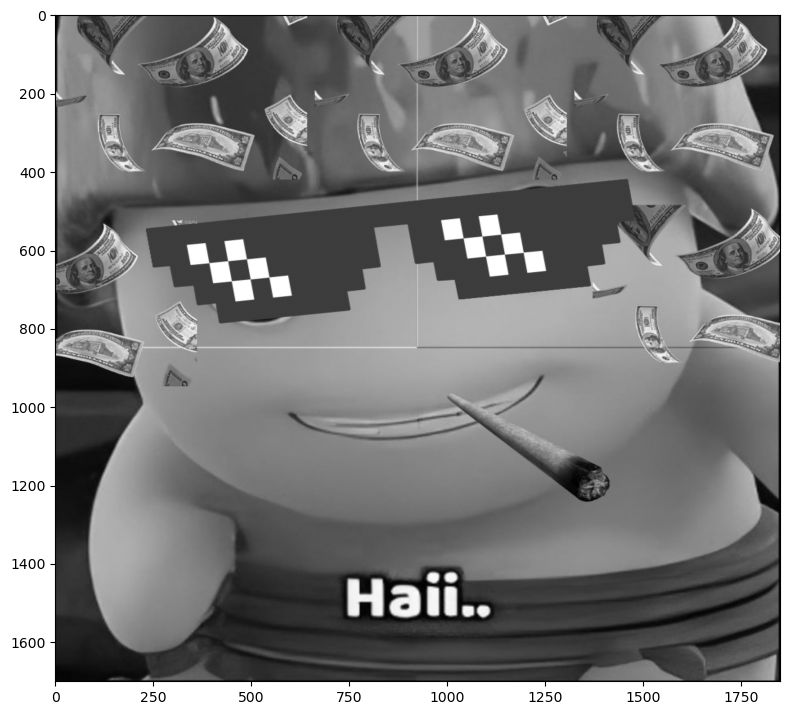

In [185]:
def crop_nonblack(img_gray, thr=10, min_fill_ratio=0.05):
    m = img_gray > thr
    rows = np.where(m.mean(axis=1) > min_fill_ratio)[0]
    cols = np.where(m.mean(axis=0) > min_fill_ratio)[0]
    if len(rows) == 0 or len(cols) == 0:
        return img_gray
    return img_gray[rows[0]:rows[-1]+1, cols[0]:cols[-1]+1]

final_no_pad = crop_nonblack(final_image_resized, thr=10, min_fill_ratio=0.05)
final_no_pad = cv2.resize(final_no_pad, (1850, 1700), interpolation=cv2.INTER_CUBIC)

base = cv2.cvtColor(final_no_pad, cv2.COLOR_GRAY2BGR)
# --- lanjut overlay ---
base = overlay_png(base, money, 0, 0, base.shape[1], base.shape[0], alpha_scale=0.95)
base = overlay_png(base, kacamata_trim, x=230, y=420, w=1250, h=370, alpha_scale=1.0)
base = overlay_png(base, udud_trim, x=1000, y=965, w=420, h=280, alpha_scale=1.0)

# output grayscale
result_gray = cv2.cvtColor(base, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(8, 8))
plt.imshow(result_gray, cmap='gray')
plt.axis('on')
plt.tight_layout()
plt.show()


## Membandingkan Histogram Dua Citra

Kode ini bertujuan untuk menghitung dan memvisualisasikan perbandingan distribusi frekuensi nilai intensitas piksel (histogram) dari dua gambar *grayscale*, yaitu representasi piksel dari variabel `final_no_pad` dan `result_gray`.

### Konversi Tipe Data
`new_image_gray` dan `gabungan_gray` didefinisikan dengan mengonversi matriks sebelumnya menggunakan `.astype(np.uint8)`. Konversi ini memastikan tipe data array adalah **Unsigned Integer 8-bit**. Ini adalah format standar untuk citra komputer di mana nilai setiap piksel harus berupa bilangan bulat dalam rentang **0 (hitam pekat)** hingga **255 (putih terang)**.

### Perhitungan Histogram (`cv2.calcHist`)
Fungsi `cv2.calcHist()` dari library OpenCV digunakan untuk mengkalkulasi seberapa sering setiap nilai piksel (0-255) muncul di dalam gambar. Berikut adalah rincian dari parameter yang diberikan:

| Parameter | Nilai pada Kode | Penjelasan |
| :--- | :--- | :--- |
| **images** | `[new_image_gray]` | Citra sumber yang akan dihitung, wajib dibungkus dalam bentuk list `[]`. |
| **channels** | `[0]` | Indeks *channel* yang dievaluasi. Angka 0 digunakan karena ini adalah citra *grayscale* (hanya memiliki 1 *channel*). |
| **mask** | `None` | Tidak ada area yang diabaikan. Histogram dihitung secara utuh dari seluruh area piksel gambar. |
| **histSize** | `[256]` | Jumlah *bin*. Menggunakan 256 berarti setiap nilai intensitas piksel (0 sampai 255) memiliki perhitungan frekuensinya masing-masing. |
| **ranges** | `[0, 256]` | Jangkauan nilai piksel yang dibaca (batas atas 256 bersifat eksklusif, sehingga rentang yang terbaca pas pada 0-255). |

Di akhir pemanggilan fungsi, `.ravel()` digunakan untuk memipihkan (*flatten*) hasil perhitungan array 2D dari OpenCV menjadi array 1D. Hal ini diwajibkan agar data bisa dipetakan menjadi garis linier oleh Matplotlib.

### Visualisasi Atribut dengan Matplotlib
Proses pembentukan grafik dilakukan secara spesifik agar perbandingan mudah dianalisis secara visual:

* **Ukuran & Pemetaan Garis**: `plt.figure(figsize=(10, 5))` membuat kanvas ukuran 10x5 inci. Fungsi `plt.plot()` menggambar garis distribusi piksel. Penggunaan `zorder` mengatur tumpukan visual; `zorder=3` (oranye) memastikan garis "Gabungan" akan digambar di atas garis "New Image" (`zorder=2`, biru).
* **Batas Tampilan (Limits)**: `plt.xlim(-5, 260)` memberikan sedikit ruang kosong di kiri dan kanan sumbu X (nilai piksel) agar garis grafik di ujung 0 dan 255 tidak menyentuh garis tepi kanvas. Batas sumbu Y dipatok di `plt.ylim(0, 255000)`.
* **Penanda Sumbu (Ticks)**: Alih-alih membiarkan Matplotlib menentukan angka di pinggir sumbu secara otomatis, `plt.xticks` memaksakan label pada sumbu X untuk muncul hanya pada interval 50 (0, 50, 100, dst.), dan `plt.yticks` memaksakan sumbu Y berinterval 50.000.
* **Finishing**: `plt.tight_layout()` digunakan untuk mencegah ada elemen grafik (seperti teks label atau legend) yang terpotong saat dirender oleh `plt.show()`.

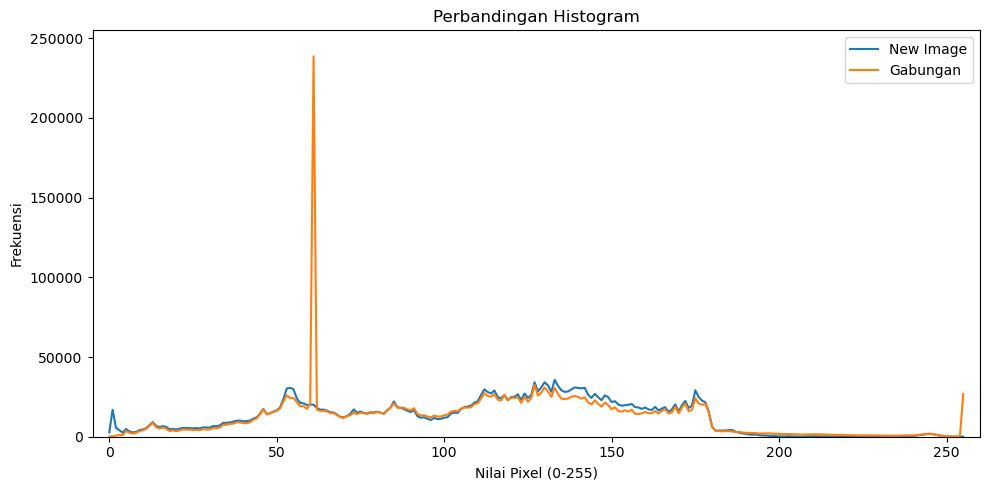

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

new_image_gray = final_no_pad.astype(np.uint8)

gabungan_gray = result_gray.astype(np.uint8)

hist_new = cv2.calcHist([new_image_gray], [0], None, [256], [0, 256]).ravel()
hist_gabungan = cv2.calcHist([gabungan_gray], [0], None, [256], [0, 256]).ravel()

plt.figure(figsize=(10, 5))
plt.plot(hist_new, color='tab:blue', label='New Image', linewidth=1.5, zorder=2)
plt.plot(hist_gabungan, color='tab:orange', label='Gabungan', linewidth=1.5, zorder=3)

plt.title('Perbandingan Histogram')
plt.xlabel('Nilai Pixel (0-255)')
plt.ylabel('Frekuensi')

plt.xlim(-5, 260)
plt.ylim(0, 255000)

plt.xticks([0, 50, 100, 150, 200, 250])
plt.yticks([0, 50000, 100000, 150000, 200000, 250000])

plt.legend()
plt.tight_layout()
plt.show()
